# CMS High-Mass Diphoton Spectrum

This notebook is the end-to-end high-mass diphoton example from the paper. It imports the CMS EBEB mass sample, fits finite exponential mixtures with randomized likelihood restarts, selects a mixture order with information criteria, and compares the selected fit with the background functions used in the CMS analysis.

## Roadmap

1. Load the unbinned diphoton dataset and the display binning.
2. Fit one- through four-component exponential mixtures, retaining all successful restart results.
3. Plot AIC/BIC model-selection curves.
4. Fit the selected mixture and the reference analytic models, then produce the comparison and summary table.

Random restarts are required because the mixture likelihood can have several local minima. A fixed seed makes the restart sequence reproducible.

In [1]:
import ROOT
import numpy as np
import matplotlib.pyplot as plt

from tools import scale_out as so
from tools import storage as stor

from emm import data as dat
from emm import fitting
from emm import models
from emm import plotting as plot

figures_cache = stor.ensure_cache("figures")

Welcome to JupyROOT 6.30/04


In [2]:
# Load the data
x = ROOT.RooRealVar("x", "Diphoton Mass [GeV]", 500, 10_000)
data_tree = dat.get_diphoton_data(tree=True)
diphoton_data = ROOT.RooDataSet("mgg", "mgg", ROOT.RooArgSet(x), ROOT.RooFit.Import(data_tree))
n = diphoton_data.numEntries()
data_mean = diphoton_data.mean(x)
print(f"Data mean: {data_mean}")

# Get the binning for the visualization
bins = dat.get_diphoton_binning()

Data mean: 676.7652379849756


In [3]:
fit_options = [
    # ROOT.RooFit.IntegrateBins(0.0001),
    ROOT.RooFit.PrintLevel(-1),
    # ROOT.RooFit.Offset(True),
    # ROOT.RooFit.Strategy(2),
    ROOT.RooFit.Save(),
    # ROOT.RooFit.Range("fit_range")
]

## Exponential-Mixture Order Selection

The model-selection loop evaluates mixture orders $k=1,2,3,4$. For each order, it keeps all successful randomized restarts and uses the minimum NLL to calculate AIC and BIC. This separates optimizer stability from the information-criterion comparison.

In [4]:
# Do model selection
model_primitives = [
    models.ModelPrimitive(
        models.ExponentialMixtureModel,
        k, data_mean=data_mean,
        name=f"ExponentialMixture-{k}"
    ) for k in range(1, 5)
]

results = {}

seed = 42
n_restarts = 20
n_retries = 5

for mp in model_primitives:
    print(f"Fitting {mp.name}...")
    fit_results = fitting.fit_random_restarts(
        x, diphoton_data, mp,
        seed, n_restarts, n_retries,
        save=False, fit_options=fit_options,
        use_multiprocessing=False,
        return_all_results=True
    )
    if not fit_results:
        raise RuntimeError(f"No successful fits found for {mp.name}.")

    print(f"   Number of minima found: {len(fit_results)}")
    print(f"   NLLs: {[res['nll'] for res in fit_results]}")

    model = mp(x)
    best_result = min(fit_results, key=lambda res: res["nll"])
    model.set_params(best_result["final_pars"])

    k = 2 * model.n_components - 1
    aic = 2 * k + 2 * best_result["nll"]
    bic = k * np.log(diphoton_data.numEntries()) + 2 * best_result["nll"]
    print(f"   Best fit: nll = {best_result['nll']:.1f}")
    print(f"   AIC: {aic:.1f}, BIC: {bic:.1f}")
    results[model.n_components] = {
        "AIC": aic,
        "BIC": bic,
        "nll": best_result["nll"],
    }

Fitting ExponentialMixture-1...
   Number of minima found: 20
   NLLs: [31096.40622413597, 31096.406264460467, 31096.40617887499, 31096.406186865086, 31096.40617713685, 31096.40617617538, 31096.4061766218, 31096.406176716417, 31096.40617618287, 31096.406176174813, 31096.406176482244, 31096.406209224373, 31096.406328379384, 31096.406176486227, 31096.406190448346, 31096.406176184617, 31096.406336634915, 31096.406187951594, 31096.406177051882, 31096.406176193872]
   Best fit: nll = 31096.4
   AIC: 62194.8, BIC: 62201.3
Fitting ExponentialMixture-2...
   Number of minima found: 20
   NLLs: [31030.83193228571, 31030.831999826663, 31030.831934636943, 31030.83212690475, 31030.83207437216, 31030.83198159494, 31030.831924451875, 31030.83193297147, 31030.83192102516, 31030.831942252677, 31030.832089151663, 31030.832159769652, 31030.83191926795, 31030.832029815483, 31030.831910051333, 31030.83212106644, 31030.832666954862, 31030.831938737738, 31030.831912633745, 31030.83195097478]
   Best fit: nl

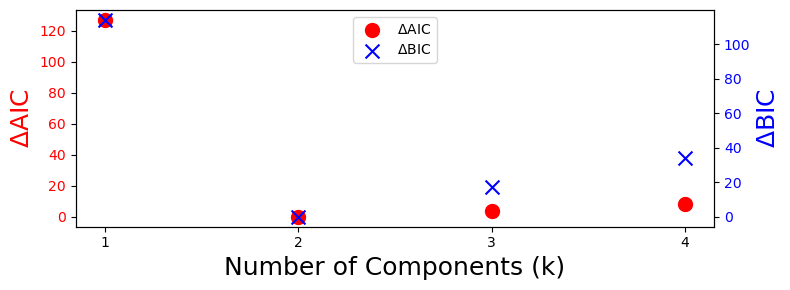

In [7]:
criteria_by_k = {}
n_observations = diphoton_data.numEntries()
for k, result in results.items():

    criteria_by_k[k] = fitting.compute_information_criteria(
        result["nll"],
        2 * k - 1,
        n_observations,
    )

_ = plot.plot_information_criteria(
    criteria_by_k,
    save_as=f"{figures_cache}/diphoton_model_selection.pdf"
)

## Reference-Function Comparison

After choosing a representative exponential mixture, this section fits it together with the analytic background functions used for the CMS comparison. The common dataset, fit options, and display binning make the resulting likelihood, goodness-of-fit, and visual comparisons directly interpretable.

In [ ]:
# Fit and plot
from emm import models as model_defs

model_primitives = [
    model_defs.ModelPrimitive(model_defs.f1),
    model_defs.ModelPrimitive(model_defs.f2),
    model_defs.ModelPrimitive(model_defs.f3),
    model_defs.ModelPrimitive(model_defs.f4),
    model_defs.ModelPrimitive(
        model_defs.ExponentialMixtureModel,
        2,
        data_mean=data_mean,
        name="ExponentialMixture-2",
    ),
]

seed = 42
n_restarts = 20
n_retries = 5

# For visualization and chi2 we bin the data
from array import array
bin_array = array('d', bins)
binning = ROOT.RooBinning(len(bins) - 1, bin_array)
x.setBinning(binning)

# For chi2
hist_name = f"diphoton_binned_data_hist_{ROOT.TUUID().AsString().replace('-', '_')}"
hist = ROOT.TH1D(hist_name, "Binned Data", len(bins) - 1, bin_array)
hist.SetDirectory(0)
diphoton_data.fillHistogram(hist, ROOT.RooArgList(x))

binned_data_name = f"binned_data_{ROOT.TUUID().AsString().replace('-', '_')}"
binned_data = ROOT.RooDataHist(
    binned_data_name,
    "Binned Data",
    ROOT.RooArgList(x),
    hist,
    )

fit_models = []
model_labels = []
model_results = []
for model_primitive in model_primitives:
    print(f"Fitting model: {model_primitive.name}")
    fit_result = fitting.fit_random_restarts(
        x, diphoton_data, model_primitive,
        seed, n_restarts, n_retries,
        save=False,
        fit_options=fit_options,
        use_multiprocessing=False,
        return_all_results=False
        )
    if fit_result is None:
        raise RuntimeError(f"No successful fits found for {model_primitive.name}.")

    model = model_primitive(x)
    model.set_params(fit_result["final_pars"])
    if "ExponentialMixture" in model.name:
        model_label = "Exponential Mixture"
        table_label = model_label
    else:
        model_num = model.name.split("_")[-1]
        model_label = f"#it{{f}}_{{{model_num}}}"
        table_label = f"$f_{{{model_num}}}$"

    nll = fit_result["nll"]
    n = diphoton_data.numEntries()

    k = len(model.params())
    aic = 2 * k + 2 * nll
    bic = k * np.log(n) + 2 * nll
    print(f"   AIC: {aic:.1f}, BIC: {bic:.1f}")

    chi2_res = fitting.chi2(
        x,
        hist,
        model,
        min_events=30,
        print_chi2=True,
        )

    fit_models.append(model)
    model_labels.append(model_label)
    model_results.append({
        "model": model,
        "label": table_label,
        "nll": nll,
        "aic": aic,
        "bic": bic,
        "chi2": chi2_res["chi2"],
        "ndf": chi2_res["ndf"],
        "chi2_ndf": chi2_res["chi2_ndf"],
    })

print(fitting.format_paper_comparison_table(model_results))
models = fit_models

Fitting model: f_1
   AIC: 62070.0, BIC: 62083.1
chi2=54.17, ndf=58, chi2/ndf=0.934, 
Fitting model: f_2
   AIC: 62068.5, BIC: 62081.5
chi2=53.48, ndf=58, chi2/ndf=0.922, 
Fitting model: f_3
   AIC: 62071.0, BIC: 62084.0
chi2=54.69, ndf=58, chi2/ndf=0.943, 
Fitting model: f_4
   AIC: 62070.3, BIC: 62089.9
chi2=53.40, ndf=57, chi2/ndf=0.937, 
Fitting model: ExponentialMixture-2
   AIC: 62067.7, BIC: 62087.2
chi2=50.58, ndf=57, chi2/ndf=0.887, 
[#1] INFO:NumericIntegration -- RooRealIntegral::init(f_1_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:NumericIntegration -- RooRealIntegral::init(f_1_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] 

[#1] INFO:NumericIntegration -- RooRealIntegral::init(f_1_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:NumericIntegration -- RooRealIntegral::init(f_2_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:NumericIntegration -- RooRealIntegral::init(f_3_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:NumericIntegration -- RooRealIntegral::init(f_4_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)


Info in <TCanvas::Print>: png file /users/atownse2/Public/FiniteExponentialMixtures/cache/figures/diphoton_fit.png has been created


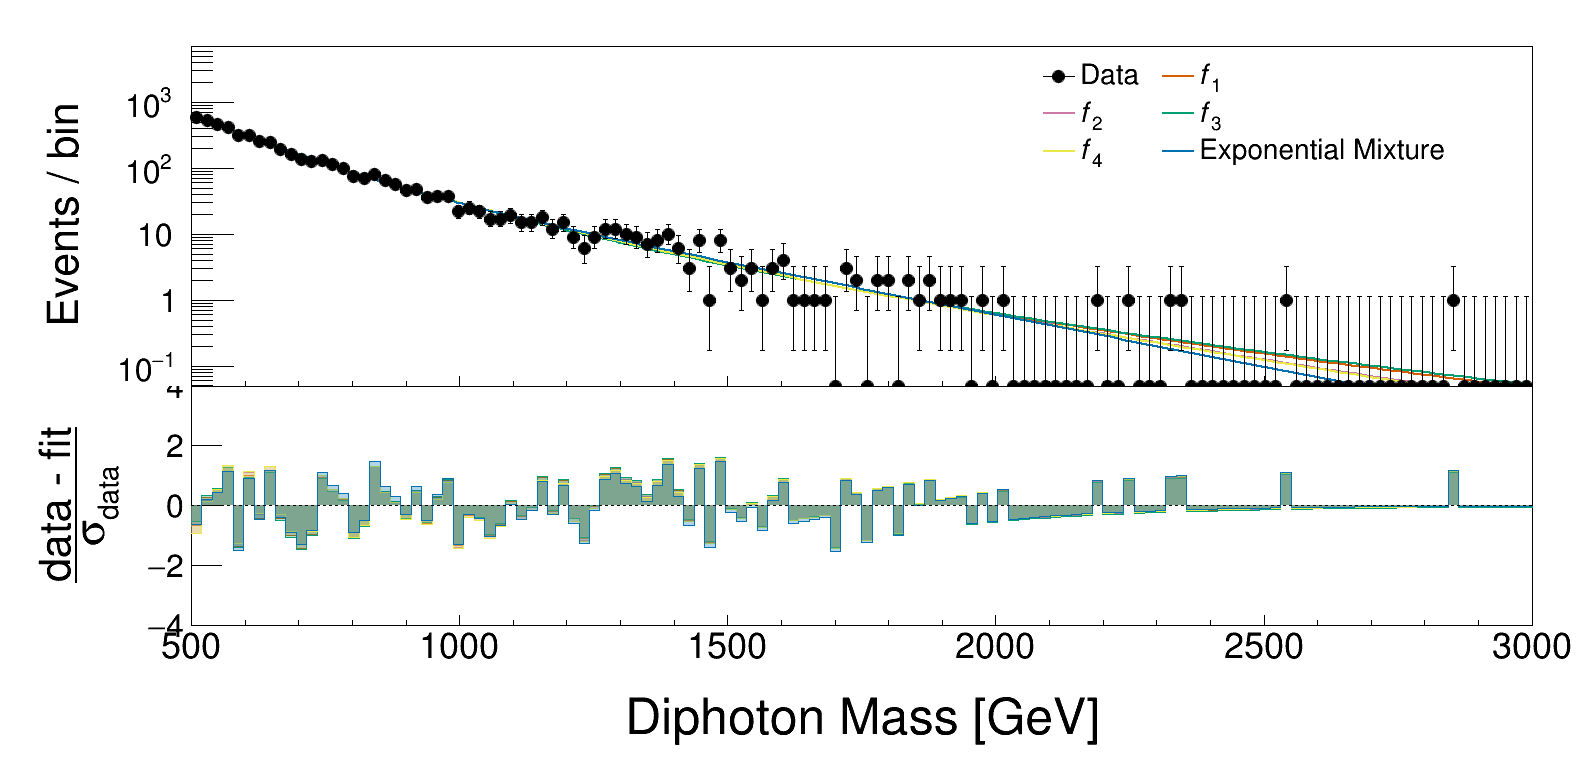

In [7]:
_ = plot.plot_fits(
    diphoton_data, x, models,
    labels=model_labels,
    # title="CMS High Mass Diphoton Spectrum",
    # colors=[ROOT.kRed],
    plot_range=(500, 3000),
    nbins=128,
    y_min=5e-2,
    # logx=True,
    legend_bounds=(0.65, 0.56, 0.95, 0.85),
    legend_text_size=0.08,
    legend_columns=2,
    pull_fill_alpha=0.3,
    save_as=f"{figures_cache}/diphoton_fit.png"
    )